<a href="https://colab.research.google.com/github/ihmkusuma/machine-learning-assignment-ilham-kusuma-4222311030/blob/main/Working%20on%20Machine%20Learning/Data%20Exploration%20and%20Data%20Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature** **Engineering**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

#Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
#Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_column', None)
pd.set_option('display.max_rows', None)


##B. Outer Handling

Assignment 1.A:
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']


Kolom : MedInc
  Q1            : 2.5634
  Q3            : 4.7432
  IQR           : 2.1799
  Lower Bound   : -0.7064
  Upper Bound   : 8.0130
  Jumlah Outlier: 681 dari 20640 data (3.30%)

Kolom : HouseAge
  Q1            : 18.0000
  Q3            : 37.0000
  IQR           : 19.0000
  Lower Bound   : -10.5000
  Upper Bound   : 65.5000
  Jumlah Outlier: 0 dari 20640 data (0.00%)

Kolom : AveRooms
  Q1            : 4.4407
  Q3            : 6.0524
  IQR           : 1.6117
  Lower Bound   : 2.0232
  Upper Bound   : 8.4699
  Jumlah Outlier: 511 dari 20640 data (2.48%)

Kolom : AveBedrms
  Q1            : 1.0061
  Q3            : 1.0995
  IQR           : 0.0934
  Lower Bound   : 0.8659
  Upper Bound   : 1.2397
  Jumlah Outlier: 1424 dari 20640 data (6.90%)

Kolom : AveOccup
  Q1            : 2.4297
  Q3            : 3.2823
  IQR           : 0.8525
  Lower Bound   : 1.1510
  Upper Bound   : 4.5610
  Jumlah Outlier: 711 dari 20640 data (3.44%)


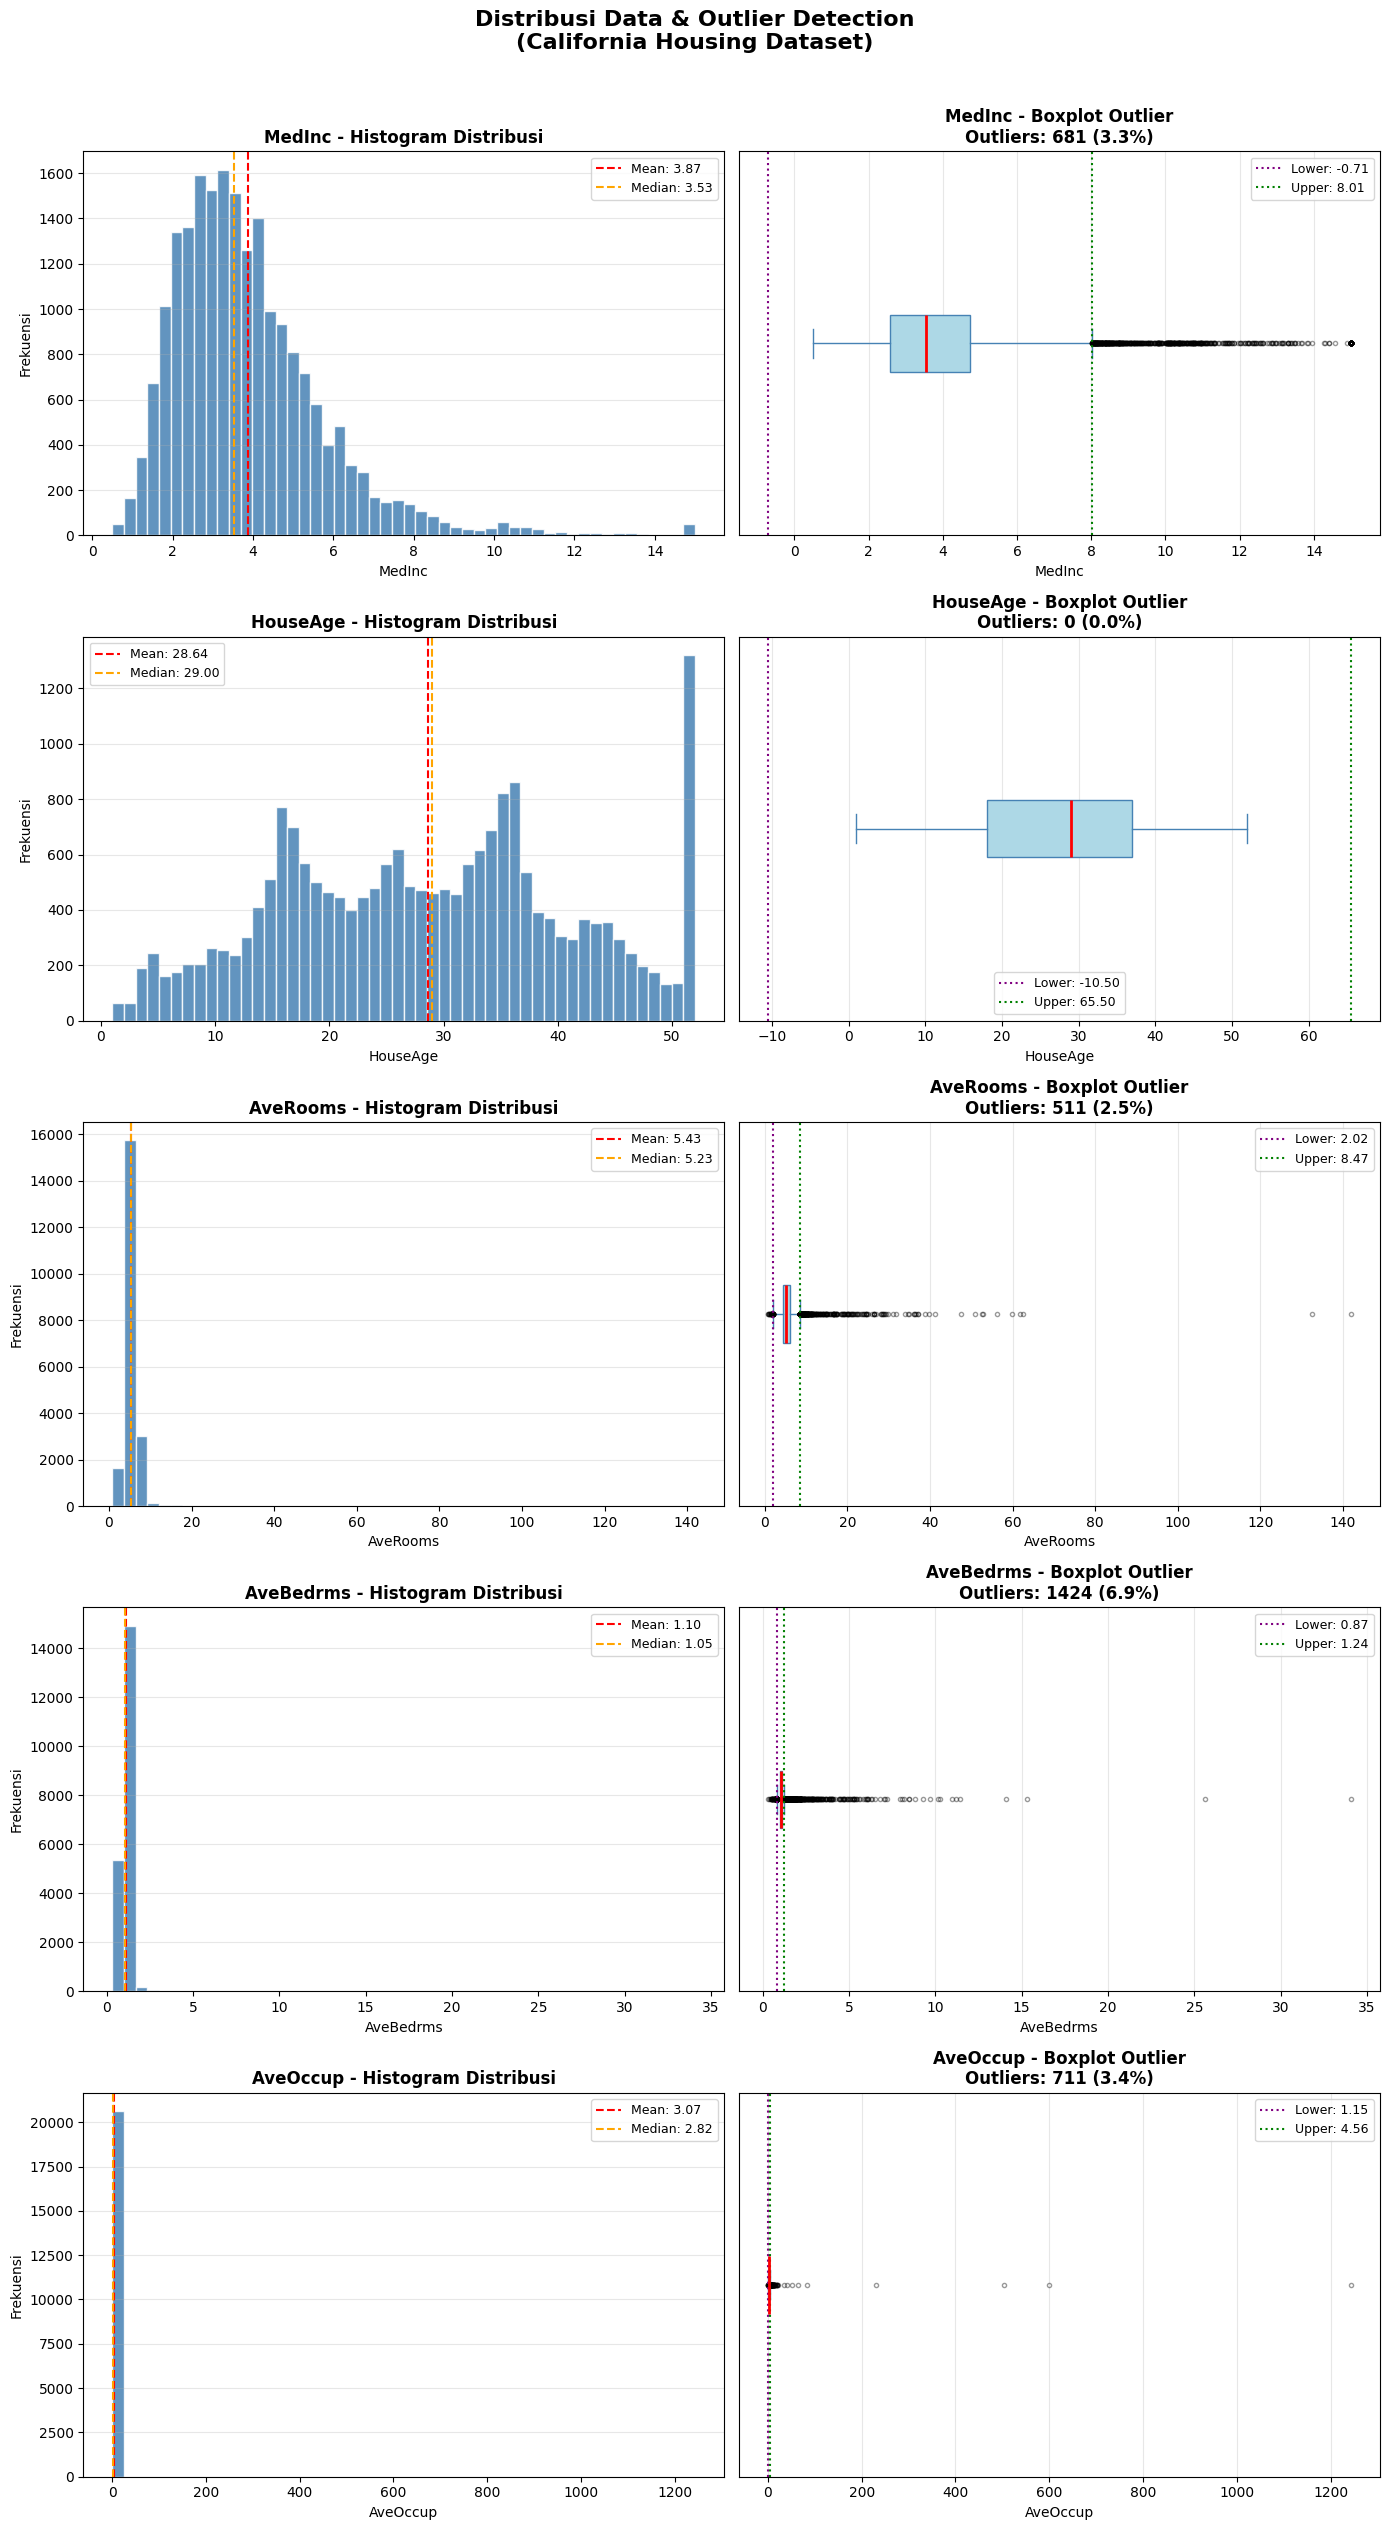

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

california_dataset = pd.read_csv('/content/california_dataset.csv')

# ============================================================
# Assignment 1.a
# ============================================================
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

fig, axes = plt.subplots(nrows=len(kolom_kolom), ncols=2, figsize=(14, 5 * len(kolom_kolom)))
fig.suptitle('Distribusi Data & Outlier Detection\n(California Housing Dataset)',
             fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(kolom_kolom):
    data = california_dataset[col]

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    # Plot 1: Histogram
    ax_hist = axes[i, 0]
    ax_hist.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax_hist.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax_hist.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax_hist.set_title(f'{col} - Histogram Distribusi', fontsize=12, fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frekuensi')
    ax_hist.legend(fontsize=9)
    ax_hist.grid(axis='y', alpha=0.3)

    # Plot 2: Boxplot
    ax_box = axes[i, 1]
    ax_box.boxplot(data, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='steelblue'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='steelblue'),
                   capprops=dict(color='steelblue'),
                   flierprops=dict(marker='o', color='tomato', alpha=0.4, markersize=3))
    ax_box.set_title(f'{col} - Boxplot Outlier\nOutliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)', fontsize=12, fontweight='bold')
    ax_box.set_xlabel(col)
    ax_box.set_yticks([])
    ax_box.axvline(lower_bound, color='purple', linestyle=':', linewidth=1.5, label=f'Lower: {lower_bound:.2f}')
    ax_box.axvline(upper_bound, color='green', linestyle=':', linewidth=1.5, label=f'Upper: {upper_bound:.2f}')
    ax_box.legend(fontsize=9)
    ax_box.grid(axis='x', alpha=0.3)

    print(f"\n{'='*50}")
    print(f"Kolom : {col}")
    print(f"  Q1            : {Q1:.4f}")
    print(f"  Q3            : {Q3:.4f}")
    print(f"  IQR           : {IQR:.4f}")
    print(f"  Lower Bound   : {lower_bound:.4f}")
    print(f"  Upper Bound   : {upper_bound:.4f}")
    print(f"  Jumlah Outlier: {len(outliers)} dari {len(data)} data ({len(outliers)/len(data)*100:.2f}%)")

plt.tight_layout()
plt.show()

Assignment 1.B
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

Q1           : 2.4297
Q3           : 3.2823
IQR          : 0.8525
Lower Bound  : 1.1510
Upper Bound  : 4.5610
Outlier sebelum handling: 711

Jumlah data sebelum : 20640
Jumlah data sesudah : 19929
Data terhapus       : 711


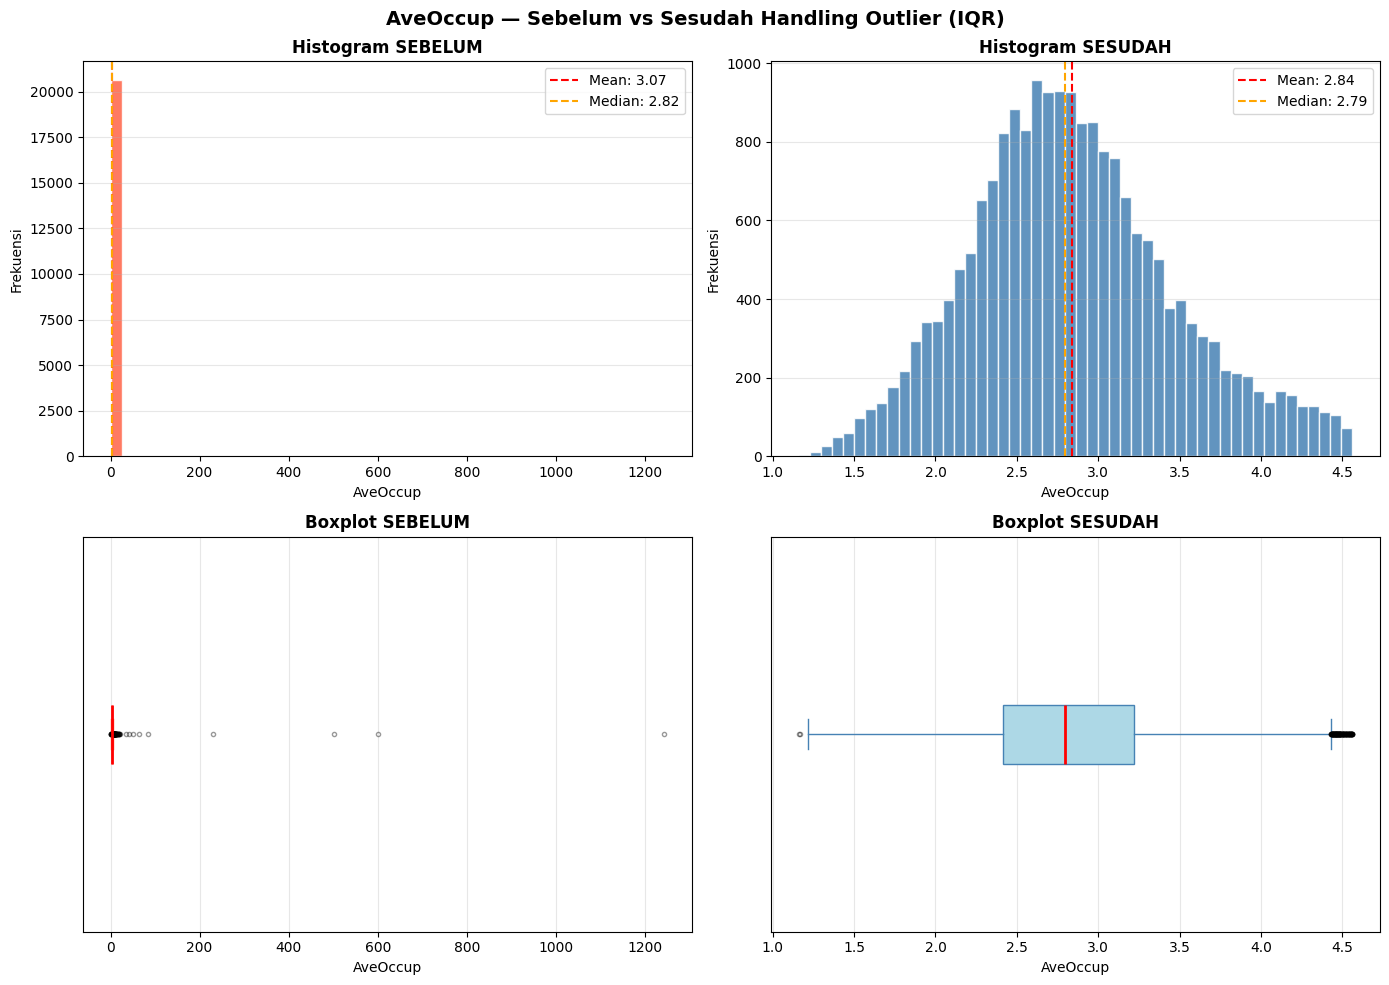


--- Statistik Deskriptif ---
Metrik            Sebelum      Sesudah
--------------------------------------
Mean               3.0707       2.8416
Median             2.8181       2.7930
Std               10.3860       0.6267
Min                0.6923       1.1613
Max             1243.3333       4.5607


In [ ]:
# ============================================================
# Assignment 1.b — Outlier Handling dengan IQR: Kolom AveOccup
# ============================================================

kolom_target = 'AveOccup'
data = california_dataset[kolom_target]

# --- Hitung IQR ---
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1           : {Q1:.4f}")
print(f"Q3           : {Q3:.4f}")
print(f"IQR          : {IQR:.4f}")
print(f"Lower Bound  : {lower_bound:.4f}")
print(f"Upper Bound  : {upper_bound:.4f}")
print(f"Outlier sebelum handling: {((data < lower_bound) | (data > upper_bound)).sum()}")

# --- Handling: hapus baris yang mengandung outlier ---
california_clean = california_dataset[(california_dataset[kolom_target] >= lower_bound) &
                                       (california_dataset[kolom_target] <= upper_bound)].copy()

print(f"\nJumlah data sebelum : {len(california_dataset)}")
print(f"Jumlah data sesudah : {len(california_clean)}")
print(f"Data terhapus       : {len(california_dataset) - len(california_clean)}")

# --- Cek distribusi sebelum vs sesudah ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('AveOccup — Sebelum vs Sesudah Handling Outlier (IQR)',
             fontsize=14, fontweight='bold')

before = california_dataset[kolom_target]
after  = california_clean[kolom_target]

# Histogram sebelum
axes[0, 0].hist(before, bins=50, color='tomato', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(before.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {before.mean():.2f}')
axes[0, 0].axvline(before.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {before.median():.2f}')
axes[0, 0].set_title('Histogram SEBELUM', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel(kolom_target)
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram sesudah
axes[0, 1].hist(after, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(after.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {after.mean():.2f}')
axes[0, 1].axvline(after.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {after.median():.2f}')
axes[0, 1].set_title('Histogram SESUDAH', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel(kolom_target)
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Boxplot sebelum
axes[1, 0].boxplot(before, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', color='tomato'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='tomato'),
                   capprops=dict(color='tomato'),
                   flierprops=dict(marker='o', color='tomato', alpha=0.4, markersize=3))
axes[1, 0].set_title('Boxplot SEBELUM', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel(kolom_target)
axes[1, 0].set_yticks([])
axes[1, 0].grid(axis='x', alpha=0.3)

# Boxplot sesudah
axes[1, 1].boxplot(after, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='steelblue'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='steelblue'),
                   capprops=dict(color='steelblue'),
                   flierprops=dict(marker='o', color='tomato', alpha=0.4, markersize=3))
axes[1, 1].set_title('Boxplot SESUDAH', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel(kolom_target)
axes[1, 1].set_yticks([])
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Perbandingan statistik deskriptif ---
print("\n--- Statistik Deskriptif ---")
print(f"{'Metrik':<12} {'Sebelum':>12} {'Sesudah':>12}")
print("-" * 38)
for stat, b, a in zip(
    ['Mean', 'Median', 'Std', 'Min', 'Max'],
    [before.mean(), before.median(), before.std(), before.min(), before.max()],
    [after.mean(),  after.median(),  after.std(),  after.min(),  after.max()]
):
    print(f"{stat:<12} {b:>12.4f} {a:>12.4f}")

## C. Missing Value Handling

Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/company.csv')
col = 'Headquarters'

# Cek semua jenis missing value
null_count    = df[col].isnull().sum()
minus1_count  = (df[col] == '-1').sum()
unknown_count = (df[col].str.lower().str.strip() == 'unknown').sum()
na_str_count  = (df[col].str.lower().str.strip() == 'n/a').sum()
empty_count   = (df[col].str.strip() == '').sum()

total_missing = null_count + minus1_count + unknown_count + na_str_count + empty_count
total_rows    = len(df)

print(f"{'='*45}")
print(f"  Analisis Missing Value: '{col}'")
print(f"{'='*45}")
print(f"Total baris              : {total_rows}")
print(f"")
print(f"Jenis Missing Value:")
print(f"  NaN / null             : {null_count}")
print(f"  String '-1'            : {minus1_count}")
print(f"  String 'unknown'       : {unknown_count}")
print(f"  String 'n/a'           : {na_str_count}")
print(f"  String kosong ('')     : {empty_count}")
print(f"{'='*45}")
print(f"Total missing value      : {total_missing}")
print(f"Persentase missing value : {total_missing/total_rows*100:.2f}%")

  Analisis Missing Value: 'Headquarters'
Total baris              : 672

Jenis Missing Value:
  NaN / null             : 0
  String '-1'            : 31
  String 'unknown'       : 0
  String 'n/a'           : 0
  String kosong ('')     : 0
Total missing value      : 31
Persentase missing value : 4.61%


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/company.csv')
col = 'Headquarters'

# Step 1 : Ubah '-1' menjadi NaN dulu
df[col] = df[col].replace('-1', np.nan)

missing_pct = df[col].isnull().sum() / len(df) * 100
print(f"Persentase missing value : {missing_pct:.2f}%")
print(f"Keputusan                : {'DROP kolom' if missing_pct > 20 else 'TIDAK di-drop, lakukan handling'}")

# Step 2 : Handling dengan Modus (data kategorikal)
modus = df[col].mode()[0]
print(f"\nModus kolom '{col}'  : {modus}")
print(f"Jumlah missing sebelum   : {df[col].isnull().sum()}")

df[col] = df[col].fillna(modus)

print(f"Jumlah missing sesudah   : {df[col].isnull().sum()}")

# Step 3 : Cek hasil
print(f"\n--- Distribusi Top 10 '{col}' setelah handling ---")
print(df[col].value_counts().head(10))

Persentase missing value : 4.61%
Keputusan                : TIDAK di-drop, lakukan handling

Modus kolom 'Headquarters'  : New York, NY
Jumlah missing sebelum   : 31
Jumlah missing sesudah   : 0

--- Distribusi Top 10 'Headquarters' setelah handling ---
Headquarters
New York, NY                 64
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Name: count, dtype: int64


## D. Encoding

Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csvs

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/TelcoCustomerChurn.csv')

kolom_kolom = ['StreamingMovies', 'StreamingTV', 'TechSupport',
               'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# ============================================================
# Step 1 : Ganti nilai yang tidak sesuai menjadi 'No'
# ============================================================
for col in kolom_kolom:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Validasi value_counts
print("=== Validasi value_counts setelah replace ===\n")
for col in kolom_kolom:
    print(f"{col}:")
    print(df[col].value_counts())
    print()

# ============================================================
# Step 2 : Label Encoder
# ============================================================
le = LabelEncoder()

for col in kolom_kolom:
    df[col] = le.fit_transform(df[col])

print("=== Hasil Label Encoding ===\n")
for col in kolom_kolom:
    print(f"{col}: {df[col].unique()}  → (No=0, Yes=1)")

print("\n--- Preview DataFrame ---")
print(df[kolom_kolom].head())

=== Validasi value_counts setelah replace ===

StreamingMovies:
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64

StreamingTV:
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64

TechSupport:
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64

MultipleLines:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

=== Hasil Label Encoding ===

StreamingMovies: [0 1]  → (No=0, Yes=1)
StreamingTV: [0 1]  → (No=0, Yes=1)
TechSupport: [0 1]  → (No=0, Yes=1)
DeviceProtection: [0 1]  → (No=0, Yes=1)
OnlineBackup: [1 0]  → (No=0, Yes=1)
OnlineSecurity: [0 1]  → (No=0, Yes=1)
MultipleLines: [0 1]  → (No=0, Yes=1)

--- Preview DataFrame ---
   StreamingMovies  StreamingTV  TechSupport  DeviceProtection  Onl